In [99]:
import pandas as pd
import numpy as np
import statsmodels.api as sm 
import scipy.stats as stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from scipy.stats import skew 
from scipy.stats import kurtosis
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FuncFormatter


In [100]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'
#fpath = 'C:\\Users\\gianl\\Desktop\\Actigraphy Sara'

__Mean exposure to light__

In [101]:
df = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'Mean_light')

In [103]:
#in column timerange_0night, 0 is day, 1 is night 
#rename as day and night
df['timerange_0night'] = df['timerange_0night'].replace({0: 'night', 1: 'day'})
df['location_0_ita'] = df['location_0_ita'].replace({0: 'ita', 1: 'uk'})

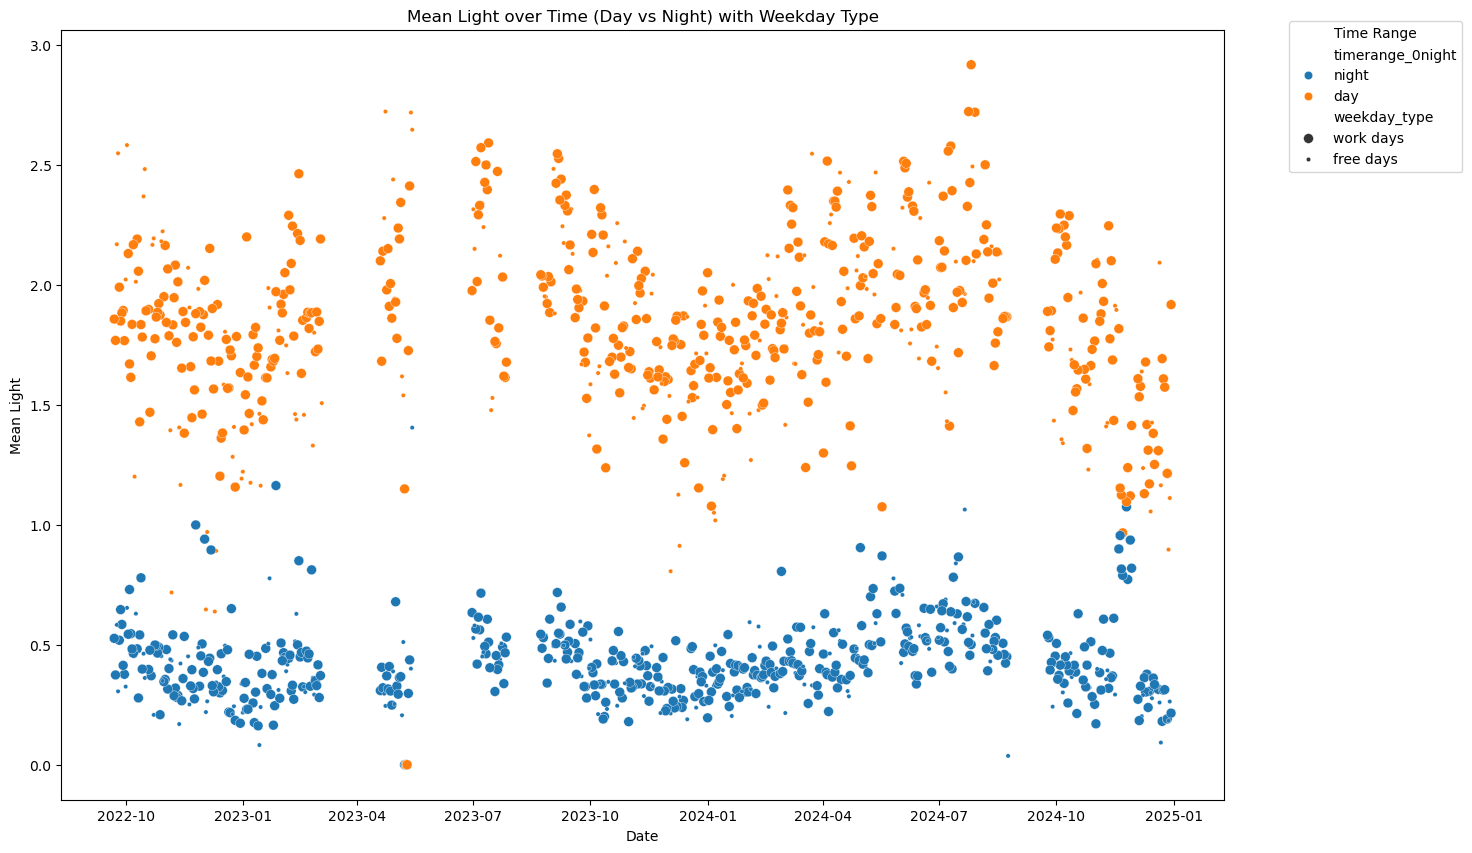

In [104]:
# Plot the mean light data over time, marking night and day, grouped by season and weekday_type
plt.figure(figsize=(15, 10))
sns.scatterplot(x='date_start', y='mean_light', hue='timerange_0night', size='weekday_type', data=df, sizes=(10, 50))
plt.xlabel('Date')
plt.ylabel('Mean Light')
plt.title('Mean Light over Time (Day vs Night) with Weekday Type')
plt.legend(title='Time Range')
plt.legend(title='Time Range', bbox_to_anchor=(1.05, 1.02), loc='upper left')

plt.show()

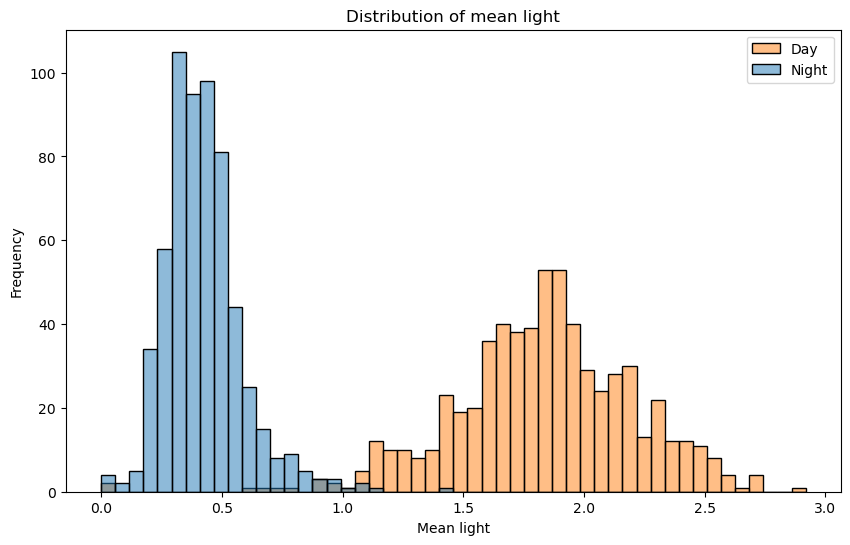

In [107]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='mean_light', kde = False, bins = 50, hue='timerange_0night')
plt.xlabel('Mean light')
plt.ylabel('Frequency')
plt.title('Distribution of mean light')
plt.legend(['Day', 'Night'])
plt.show()

In [127]:
df_day = df[df['timerange_0night'] == 'day']

In [128]:
df_night = df[df['timerange_0night'] == 'night']

In [112]:
shapiro_test = stats.shapiro(df['mean_light'])
shapiro_test_day = stats.shapiro(df_day['mean_light'])   
shapiro_test_night = stats.shapiro(df_night['mean_light'])

In [113]:
shapiro_test, shapiro_test_day, shapiro_test_night

(ShapiroResult(statistic=0.8742765936730893, pvalue=2.558820963835577e-30),
 ShapiroResult(statistic=0.9815828902691466, pvalue=4.2239380661874333e-07),
 ShapiroResult(statistic=0.9294851364448025, pvalue=3.5731622223144606e-16))

In [114]:
utest_location = stats.mannwhitneyu(df_day[df_day['location_0_ita'] == 'ita']['mean_light'], df_day[df_day['location_0_ita'] == 'uk']['mean_light'])

utest_location

MannwhitneyuResult(statistic=43670.0, pvalue=0.040312794487105535)

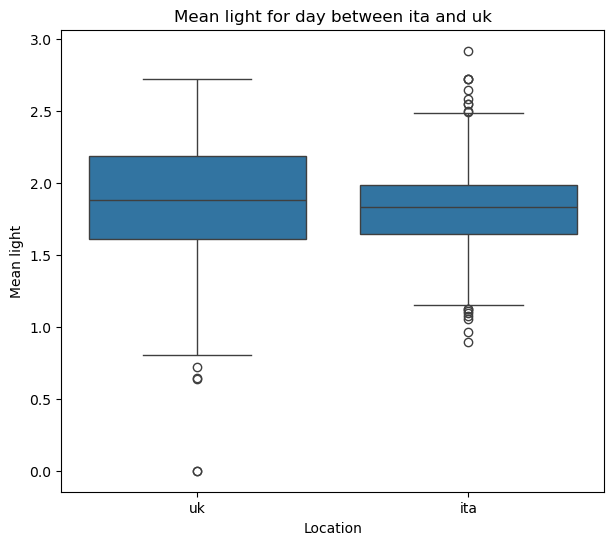

In [141]:
# box plot of mean light for day between ita and uk
plt.figure(figsize=(7, 6))
sns.boxplot(data=df_day, x='location_0_ita', y='mean_light')
plt.xlabel('Location')
plt.ylabel('Mean light')
plt.title('Mean light for day between ita and uk')
plt.show()

In [132]:
# descriptive statistics by location
df_day_loc = df_day.groupby('location_0_ita').describe()

df_day_loc

mean_light                                                   \
                    count      mean       min       25%       50%      75%   
location_0_ita                                                               
ita                 355.0  1.818815  0.896877  1.644404  1.835233  1.98386   
uk                  272.0  1.852032  0.000000  1.611329  1.878265  2.18758   

                                   median            ... flight_id             \
                     max       std  count      mean  ...       max        std   
location_0_ita                                       ...                        
ita             2.918862  0.318746  355.0  1.895914  ...      47.0  14.279972   
uk              2.719547  0.438040  272.0  1.997782  ...      46.0  13.148500   

               photoperiod                                            \
                     count       mean       min       25%        50%   
location_0_ita                                                         
ita                  355.0  11.453615  8.716667  9.300000  10.850000   
uk                   272.0  11.442892  7.850000  9.008333  10.983333   

                                                
                      75%        max       std  
location_0_ita                                  
ita             13.708333  15.683333  2.278100  
uk              14.779167  16.616667  3.031956  

[2 rows x 72 columns]

In [115]:
utest_location = stats.mannwhitneyu(df_night[df_night['location_0_ita'] == 'ita']['mean_light'], df_night[df_night['location_0_ita'] == 'uk']['mean_light'])

utest_location

MannwhitneyuResult(statistic=44688.0, pvalue=0.874177732476869)

In [ ]:
# Regression analysis for day
model_day = smf.ols(
    "mean_light ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_day
).fit()

# Display the regression summaries
model_day.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             mean_light   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     63.45
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           8.33e-36
Time:                        15:34:22   Log-Likelihood:                -190.99
No. Observations:                 627   AIC:                             390.0
Df Residuals:                     623   BIC:                             407.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.9916      0.063     15.644      0.000       0.867       1.116
location_0_ita[T.uk]             0.0320      0.027      1.206      0.228      -0.020       0.084
C(weekday_type)[T.work days]     0.0759      0.029      2.620      0.009       0.019       0.133
photoperiod                      0.0676      0.005     13.508      0.000       0.058       0.077
==============================================================================
Omnibus:                      157.381   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              792.666
Skew:                          -1.025   Prob(JB):                    7.50e-173
Kurtosis:                       8.113   Cond. No.                         58.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [142]:
# Regression analysis for night
model_night = smf.ols(
    "mean_light ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_night
).fit()

model_night.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             mean_light   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     30.45
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           2.53e-18
Time:                        15:40:23   Log-Likelihood:                 284.50
No. Observations:                 599   AIC:                            -561.0
Df Residuals:                     595   BIC:                            -543.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.1646      0.030      5.542      0.000       0.106       0.223
C(location_0_ita)[T.uk]         -0.0186      0.012     -1.496      0.135      -0.043       0.006
C(weekday_type)[T.work days]     0.0253      0.014      1.851      0.065      -0.002       0.052
photoperiod                      0.0218      0.002      9.319      0.000       0.017       0.026
==============================================================================
Omnibus:                      208.548   Durbin-Watson:                   1.931
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1082.626
Skew:                           1.464   Prob(JB):                    8.14e-236
Kurtosis:                       8.900   Cond. No.                         57.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Seasons

In [137]:
df_day_summer = df_day[df_day['season'] == 'Summer']
df_night_summer = df_night[df_night['season'] == 'Summer']

df_day_winter = df_day[df_day['season'] == 'Winter']
df_night_winter = df_night[df_night['season'] == 'Winter']

-In Summer

In [ ]:
utest_loc_day_s = stats.mannwhitneyu(df_day_summer[df_day_summer['location_0_ita'] == 'ita']['mean_light'], df_day_summer[df_day_summer['location_0_ita'] == 'uk']['mean_light'])

utest_loc_day_s

MannwhitneyuResult(statistic=1043.0, pvalue=0.010368711640754627)

In [139]:
summer_day_loc = df_day_summer.groupby('location_0_ita').describe()
summer_day_loc

mean_light                                                    \
                    count      mean       min       25%       50%       75%   
location_0_ita                                                                
ita                  70.0  2.041587  1.529419  1.868908  1.976992  2.136861   
uk                   42.0  2.158136  1.412132  1.933249  2.269222  2.417872   

                                   median            ... flight_id             \
                     max       std  count      mean  ...       max        std   
location_0_ita                                       ...                        
ita             2.918862  0.266093   70.0  2.089713  ...      41.0  11.345588   
uk              2.592791  0.353014   42.0  2.331381  ...      40.0  10.476163   

               photoperiod                                              \
                     count       mean        min        25%        50%   
location_0_ita                                                           
ita                   70.0  14.360714  12.183333  13.691667  14.475000   
uk                    42.0  15.414286  12.750000  13.412500  16.308333   

                                                
                      75%        max       std  
location_0_ita                                  
ita             15.175000  15.683333  1.011623  
uk              16.458333  16.566667  1.496480  

[2 rows x 72 columns]

In [140]:
utest_loc_night_s = stats.mannwhitneyu(df_night_summer[df_night_summer['location_0_ita'] == 'ita']['mean_light'], df_night_summer[df_night_summer['location_0_ita'] == 'uk']['mean_light'])

utest_loc_night_s

MannwhitneyuResult(statistic=1225.0, pvalue=0.4440187108107567)

In [146]:
# Regression analysis for day
model_day_s = smf.ols(
    "mean_light ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_day_summer
).fit()

# Display the regression summaries
model_day.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             mean_light   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     63.45
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           8.33e-36
Time:                        15:46:42   Log-Likelihood:                -190.99
No. Observations:                 627   AIC:                             390.0
Df Residuals:                     623   BIC:                             407.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.9916      0.063     15.644      0.000       0.867       1.116
location_0_ita[T.uk]             0.0320      0.027      1.206      0.228      -0.020       0.084
C(weekday_type)[T.work days]     0.0759      0.029      2.620      0.009       0.019       0.133
photoperiod                      0.0676      0.005     13.508      0.000       0.058       0.077
==============================================================================
Omnibus:                      157.381   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              792.666
Skew:                          -1.025   Prob(JB):                    7.50e-173
Kurtosis:                       8.113   Cond. No.                         58.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [147]:
# Regression analysis for night
model_night_s = smf.ols(
    "mean_light ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_night_summer
).fit()

model_night.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             mean_light   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     30.45
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           2.53e-18
Time:                        15:46:50   Log-Likelihood:                 284.50
No. Observations:                 599   AIC:                            -561.0
Df Residuals:                     595   BIC:                            -543.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.1646      0.030      5.542      0.000       0.106       0.223
C(location_0_ita)[T.uk]         -0.0186      0.012     -1.496      0.135      -0.043       0.006
C(weekday_type)[T.work days]     0.0253      0.014      1.851      0.065      -0.002       0.052
photoperiod                      0.0218      0.002      9.319      0.000       0.017       0.026
==============================================================================
Omnibus:                      208.548   Durbin-Watson:                   1.931
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1082.626
Skew:                           1.464   Prob(JB):                    8.14e-236
Kurtosis:                       8.900   Cond. No.                         57.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

-In Winter

In [143]:
utest_loc_day_w = stats.mannwhitneyu(df_day_winter[df_day_winter['location_0_ita'] == 'ita']['mean_light'], df_day_winter[df_day_winter['location_0_ita'] == 'uk']['mean_light'])

utest_loc_day_w

MannwhitneyuResult(statistic=2770.0, pvalue=0.06862227296506647)

In [144]:
utest_loc_night_w = stats.mannwhitneyu(df_night_winter[df_night_winter['location_0_ita'] == 'ita']['mean_light'], df_night_winter[df_night_winter['location_0_ita'] == 'uk']['mean_light'])

utest_loc_night_w

MannwhitneyuResult(statistic=2178.0, pvalue=0.001496369413957493)

In [145]:
winter_night_loc = df_night_winter.groupby('location_0_ita').describe()
winter_night_loc

mean_light                                                    \
                    count      mean       min       25%       50%       75%   
location_0_ita                                                                
ita                 100.0  0.351695  0.092287  0.262407  0.328431  0.410677   
uk                   62.0  0.396669  0.082067  0.323988  0.391231  0.455863   

                                   median            ... flight_id             \
                     max       std  count      mean  ...       max        std   
location_0_ita                                       ...                        
ita             1.163978  0.149783  100.0  0.029517  ...      47.0  12.827359   
uk              0.850562  0.121800   62.0  0.018141  ...      32.0  10.298086   

               photoperiod                                                     \
                     count      mean       min       25%       50%        75%   
location_0_ita                                                                  
ita                  100.0  9.654667  8.716667  8.766667  9.341667  10.604167   
uk                    62.0  9.564247  7.983333  8.266667  9.500000   9.983333   

                                     
                      max       std  
location_0_ita                       
ita             12.166667  0.972801  
uk              11.800000  1.185088  

[2 rows x 72 columns]

In [148]:
# Regression analysis for day
model_day_s = smf.ols(
    "mean_light ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_day_winter
).fit()

# Display the regression summaries
model_day.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             mean_light   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     63.45
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           8.33e-36
Time:                        15:47:07   Log-Likelihood:                -190.99
No. Observations:                 627   AIC:                             390.0
Df Residuals:                     623   BIC:                             407.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.9916      0.063     15.644      0.000       0.867       1.116
location_0_ita[T.uk]             0.0320      0.027      1.206      0.228      -0.020       0.084
C(weekday_type)[T.work days]     0.0759      0.029      2.620      0.009       0.019       0.133
photoperiod                      0.0676      0.005     13.508      0.000       0.058       0.077
==============================================================================
Omnibus:                      157.381   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              792.666
Skew:                          -1.025   Prob(JB):                    7.50e-173
Kurtosis:                       8.113   Cond. No.                         58.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [149]:
# Regression analysis for night
model_night_s = smf.ols(
    "mean_light ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_night_winter
).fit()

model_night.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             mean_light   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     30.45
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           2.53e-18
Time:                        15:47:09   Log-Likelihood:                 284.50
No. Observations:                 599   AIC:                            -561.0
Df Residuals:                     595   BIC:                            -543.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.1646      0.030      5.542      0.000       0.106       0.223
C(location_0_ita)[T.uk]         -0.0186      0.012     -1.496      0.135      -0.043       0.006
C(weekday_type)[T.work days]     0.0253      0.014      1.851      0.065      -0.002       0.052
photoperiod                      0.0218      0.002      9.319      0.000       0.017       0.026
==============================================================================
Omnibus:                      208.548   Durbin-Watson:                   1.931
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1082.626
Skew:                           1.464   Prob(JB):                    8.14e-236
Kurtosis:                       8.900   Cond. No.                         57.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

__Time above threshold (10-100-490-1000-2500)__

_TATp10_

In [194]:
df_TATp10 = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'TATp_10')

In [ ]:
# remove outliers according to 3 standard deviations
df_TATp10 = df_TATp10[np.abs(df_TATp10['TATp10_min'] - df_TATp10['TATp10_min'].mean()) <= (3 * df_TATp10['TATp10_min'].std())]

In [228]:
df_TATp10['location_0_ita'] = df_TATp10['location_0_ita'].replace({0: 'ita', 1: 'uk'})

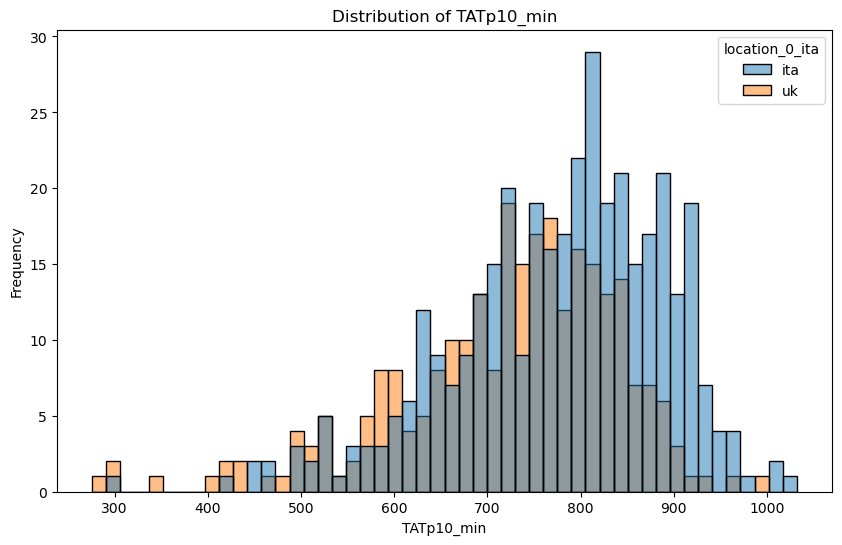

In [229]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_TATp10, x='TATp10_min', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('TATp10_min')
plt.ylabel('Frequency')
plt.title('Distribution of TATp10_min')
plt.show()

In [197]:
shapiro_test_tatp10 = stats.shapiro(df_TATp10['TATp10_min'])

shapiro_test_tatp10

ShapiroResult(statistic=0.9653724938155483, pvalue=3.0069543635476924e-11)

In [199]:
utest_location_tatp10 = stats.mannwhitneyu(df_TATp10[df_TATp10['location_0_ita'] == 'ita']['TATp10_min'], df_TATp10[df_TATp10['location_0_ita'] == 'uk']['TATp10_min'])

utest_location_tatp10

MannwhitneyuResult(statistic=64868.0, pvalue=6.866689427935188e-09)

In [200]:
# grpup by location and mean,std,min and max of 'TATp10_min
df_TATp10_loc = df_TATp10.groupby('location_0_ita').agg({'TATp10_min': ['mean', 'std', 'min', 'max']})
df_TATp10_loc

TATp10_min                           
                      mean         std    min     max
location_0_ita                                       
ita             775.219577  115.042343  301.5  1032.0
uk              721.426199  119.856342  276.0   992.5

In [201]:
# perform a multifactors ANOVA to test the effect of location, season and weekday_type on TATp10_min
model_tatp10 = ols('TATp10_min ~ C(location_0_ita) + C(season) + C(weekday_type)', data=df_TATp10).fit()
anova_table = sm.stats.anova_lm(model_tatp10, typ=3)
anova_table

,sum_sq,df,F,PR(>F)
Intercept,5.202126e+07,1.0,4636.313305,3.605427e-296
C(location_0_ita),4.199656e+05,1.0,37.428776,1.647283e-09
C(season),8.804961e+05,3.0,26.157609,5.653554e-16
C(weekday_type),7.673141e+05,1.0,68.385660,7.729579e-16
Residual,7.214713e+06,643.0,NaN,NaN


In [212]:
# Regression analysis for night
model_TATp10 = smf.ols(
    "TATp10_min ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_TATp10
).fit()

model_TATp10.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             TATp10_min   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     81.46
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           1.08e-44
Time:                        16:07:26   Log-Likelihood:                -3923.0
No. Observations:                 649   AIC:                             7854.
Df Residuals:                     645   BIC:                             7872.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                      521.2600     19.509     26.719      0.000     482.951     559.569
C(location_0_ita)[T.uk]        -53.0585      8.152     -6.509      0.000     -69.066     -37.051
C(weekday_type)[T.work days]    76.9674      8.933      8.616      0.000      59.426      94.509
photoperiod                     17.2846      1.533     11.273      0.000      14.274      20.295
==============================================================================
Omnibus:                       98.522   Durbin-Watson:                   1.294
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              190.941
Skew:                          -0.882   Prob(JB):                     3.45e-42
Kurtosis:                       4.987   Cond. No.                         58.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [256]:
#The coefficient estimate in the output indicate the average change in the log odds of the response variable associated with a one unit increase in each predictor variable.

_TATp100_

In [203]:
df_TATp100 = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'TATp_100')

In [ ]:
# remove outliers according to 3 standard deviations
#df_TATp100 = df_TATp100[np.abs(df_TATp100['TATp100_min'] - df_TATp100['TATp100_min'].mean()) <= (3 * df_TATp100['TATp100_min'].std())]

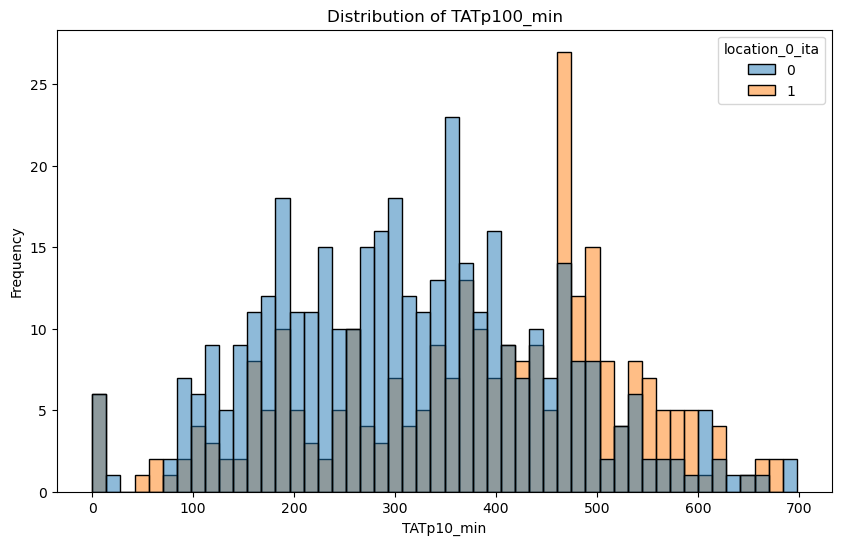

In [205]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_TATp100, x='TATp100_min', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('TATp10_min')
plt.ylabel('Frequency')
plt.title('Distribution of TATp100_min')
plt.show()

In [204]:
shapiro_test_tatp100 = stats.shapiro(df_TATp100['TATp100_min'])

shapiro_test_tatp100

ShapiroResult(statistic=0.9908388455240056, pvalue=0.0003895528353951703)

In [206]:
df_TATp100['location_0_ita'] = df_TATp100['location_0_ita'].replace({0: 'ita', 1: 'uk'})

In [207]:
utest_location_tatp100 = stats.mannwhitneyu(df_TATp100[df_TATp100['location_0_ita'] == 'ita']['TATp100_min'], df_TATp100[df_TATp100['location_0_ita'] == 'uk']['TATp100_min'])

utest_location_tatp100

MannwhitneyuResult(statistic=39033.5, pvalue=3.004991966933346e-09)

In [208]:
# by location and mean,std,min and max of 'TATp100_min
df_TATp100_loc = df_TATp100.groupby('location_0_ita').agg({'TATp100_min': ['mean', 'std', 'min', 'max']})
df_TATp100_loc

TATp100_min                        
                      mean         std  min    max
location_0_ita                                    
ita             313.915803  136.993606  0.0  698.0
uk              376.229242  151.620219  0.0  684.0

In [217]:
# Regression analysis for night
model_TATp100 = smf.ols(
    "TATp100_min ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_TATp100
).fit()

model_TATp100.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            TATp100_min   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     12.54
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           5.56e-08
Time:                        16:09:30   Log-Likelihood:                -4228.0
No. Observations:                 663   AIC:                             8464.
Df Residuals:                     659   BIC:                             8482.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                      378.4133     26.675     14.186      0.000     326.036     430.791
C(location_0_ita)[T.uk]         72.5906     11.905      6.098      0.000      49.215      95.966
C(weekday_type)[T.work days]    -2.1822     12.341     -0.177      0.860     -26.415      22.050
photoperiod                     -5.8369      2.227     -2.621      0.009     -10.210      -1.464
==============================================================================
Omnibus:                        5.272   Durbin-Watson:                   1.145
Prob(Omnibus):                  0.072   Jarque-Bera (JB):                4.893
Skew:                          -0.159   Prob(JB):                       0.0866
Kurtosis:                       2.724   Cond. No.                         58.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

_TATp490_

In [234]:
df_TATp490 = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'TATp_490')

In [ ]:
# remove outliers according to 3 standard deviations
#df_TATp490 = df_TATp490[np.abs(df_TATp490['TATp490_min'] - df_TATp490['TATp490_min'].mean()) <= (3 * df_TATp490['TATp490_min'].std())]

In [235]:
df_TATp490['location_0_ita'] = df_TATp490['location_0_ita'].replace({0: 'ita', 1: 'uk'})

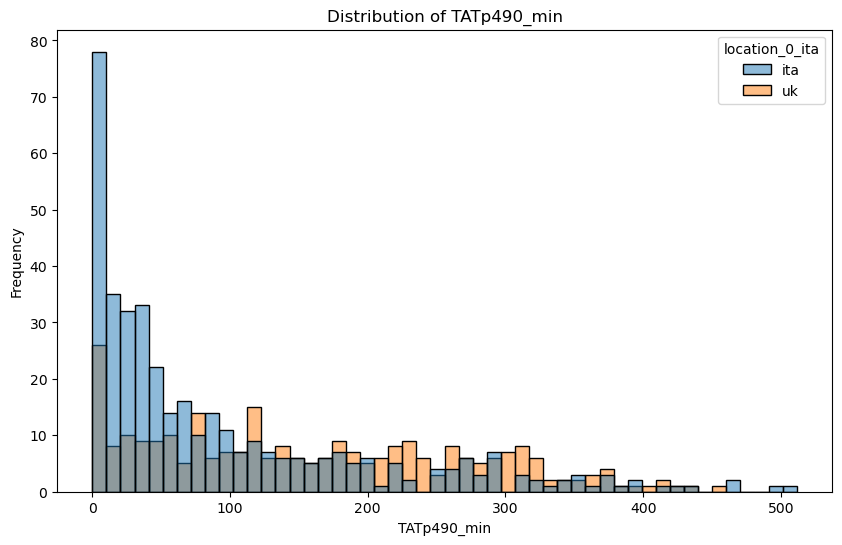

In [236]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_TATp490, x='TATp490_min', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('TATp490_min')
plt.ylabel('Frequency')
plt.title('Distribution of TATp490_min')
plt.show()

In [237]:
utest_location_tatp490 = stats.mannwhitneyu(df_TATp490[df_TATp490['location_0_ita'] == 'ita']['TATp490_min'], df_TATp490[df_TATp490['location_0_ita'] == 'uk']['TATp490_min'])

utest_location_tatp490

MannwhitneyuResult(statistic=34174.5, pvalue=2.2061834402579166e-15)

In [ ]:
# by location and mean,std,min and max of 'TATp490_min
df_TATp490_loc = df_TATp490.groupby('location_0_ita').agg({'TATp490_min': ['mean', 'std', 'min', 'max']})
df_TATp490_loc

TATp490_min                        
                      mean         std  min    max
location_0_ita                                    
ita              98.090551  109.191637  0.0  511.5
uk              160.819343  113.752789  0.0  452.0

In [266]:
# Fix: Replace zero values in TATp490_min with a small positive value
df_TATp490["TATp490_min"] = df_TATp490["TATp490_min"].replace(0, 1e-6)

# Fit a GLM with Gamma distribution and correct log link function
glm_model_fixed = smf.glm(
    "TATp490_min ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_TATp490,
    family=sm.families.Gamma(link=sm.families.links.Log())  # Fix deprecated log alias
).fit()

# Display the corrected regression summary
glm_model_fixed.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            TATp490_min   No. Observations:                  663
Model:                            GLM   Df Residuals:                      659
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                         0.95909
Method:                          IRLS   Log-Likelihood:                -3768.1
Date:                Wed, 19 Mar 2025   Deviance:                       1481.9
Time:                        17:17:45   Pearson chi2:                     632.
No. Iterations:                    23   Pseudo R-squ. (CS):             0.2481
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        3.0081      0.184     16.313      0.000       2.647       3.370
C(location_0_ita)[T.uk]          0.7079      0.077      9.179      0.000       0.557       0.859
C(weekday_type)[T.work days]    -0.5635      0.085     -6.656      0.000      -0.729      -0.398
photoperiod                      0.1529      0.014     10.600      0.000       0.125       0.181
================================================================================================
"""

In [267]:
#convert the coefficients to the original scale and print them
coef = np.exp(glm_model_fixed.params)
print(coef)

Intercept                       20.248710
C(location_0_ita)[T.uk]          2.029762
C(weekday_type)[T.work days]     0.569223
photoperiod                      1.165253
dtype: float64


In [268]:
# convert the coef in percentage
coef = np.exp(glm_model_fixed.params) - 1
coef = coef * 100
print(coef)

Intercept                       1924.871026
C(location_0_ita)[T.uk]          102.976185
C(weekday_type)[T.work days]     -43.077705
photoperiod                       16.525309
dtype: float64


_TATp1000_

In [240]:
df_TATp1000 = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'TATp_1000')

In [242]:
df_TATp1000['location_0_ita'] = df_TATp1000['location_0_ita'].replace({0: 'ita', 1: 'uk'})

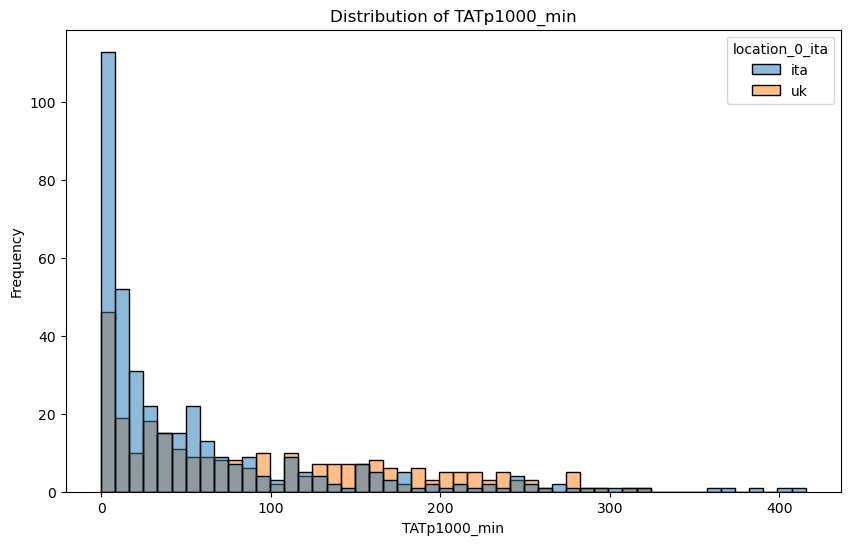

In [243]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_TATp1000, x='TATp1000_min', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('TATp1000_min')
plt.ylabel('Frequency')
plt.title('Distribution of TATp1000_min')
plt.show()

In [244]:
shapiro_test_tatp1000 = stats.shapiro(df_TATp1000['TATp1000_min'])

shapiro_test_tatp1000

ShapiroResult(statistic=0.8204288672417093, pvalue=1.4480111227687825e-26)

In [245]:
utest_location_tatp1000 = stats.mannwhitneyu(df_TATp1000[df_TATp1000['location_0_ita'] == 'ita']['TATp1000_min'], df_TATp1000[df_TATp1000['location_0_ita'] == 'uk']['TATp1000_min'])

utest_location_tatp1000

MannwhitneyuResult(statistic=38043.5, pvalue=2.289832338072761e-10)

In [ ]:
# by location and mean,std,min and max of 'TATp1000_min
df_TATp1000_loc = df_TATp1000.groupby('location_0_ita').agg({'TATp1000_min': ['mean', 'std', 'min', 'max']})
df_TATp1000_loc

TATp1000_min                       
                       mean        std  min    max
location_0_ita                                    
ita               56.931347  78.143590  0.0  415.5
uk                91.667870  82.386548  0.0  320.5

In [269]:
# Fix: Replace zero values in TATp1000_min with a small positive value
df_TATp1000["TATp1000_min"] = df_TATp1000["TATp1000_min"].replace(0, 1e-6)

# Fit a GLM with Gamma distribution and correct log link function
glm_model_fixed = smf.glm(
    "TATp1000_min ~ location_0_ita + photoperiod + C(weekday_type)",
    data=df_TATp1000,
    family=sm.families.Gamma(link=sm.families.links.Log())  # Fix deprecated log alias
).fit()

# Display the corrected regression summary
glm_model_fixed.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:           TATp1000_min   No. Observations:                  663
Model:                            GLM   Df Residuals:                      659
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                          1.4352
Method:                          IRLS   Log-Likelihood:                -3172.7
Date:                Wed, 19 Mar 2025   Deviance:                       2918.5
Time:                        17:21:18   Pearson chi2:                     946.
No. Iterations:                    17   Pseudo R-squ. (CS):            0.04029
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        4.2875      0.224     19.153      0.000       3.849       4.726
location_0_ita[T.uk]             0.5300      0.100      5.306      0.000       0.334       0.726
C(weekday_type)[T.work days]     0.0176      0.104      0.170      0.865      -0.185       0.221
photoperiod                     -0.0245      0.019     -1.311      0.190      -0.061       0.012
================================================================================================
"""

In [270]:
#convert the coefficients to the original scale and print them
coef = np.exp(glm_model_fixed.params)
print(coef)

Intercept                       72.786662
location_0_ita[T.uk]             1.699000
C(weekday_type)[T.work days]     1.017712
photoperiod                      0.975793
dtype: float64


In [271]:
# convert the coef in percentage
coef = np.exp(glm_model_fixed.params) - 1
coef = coef * 100
print(coef)

Intercept                       7178.666194
location_0_ita[T.uk]              69.900017
C(weekday_type)[T.work days]       1.771221
photoperiod                       -2.420700
dtype: float64


_TATp2500_

In [248]:
df_TATp2500 = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'TATp_2500')

In [249]:
df_TATp2500['location_0_ita'] = df_TATp2500['location_0_ita'].replace({0: 'ita', 1: 'uk'})

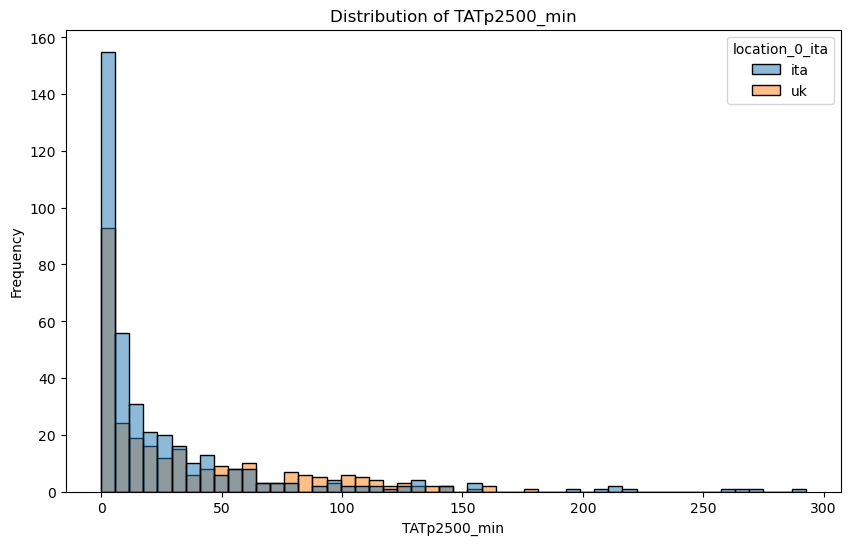

In [250]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_TATp2500, x='TATp2500_min', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('TATp2500_min')
plt.ylabel('Frequency')
plt.title('Distribution of TATp2500_min')
plt.show()

In [251]:
shapiro_test_tatp2500 = stats.shapiro(df_TATp2500['TATp2500_min'])

shapiro_test_tatp2500

ShapiroResult(statistic=0.708830045211001, pvalue=2.5013048887493885e-32)

In [252]:
utest_location_tatp2500 = stats.mannwhitneyu(df_TATp2500[df_TATp2500['location_0_ita'] == 'ita']['TATp2500_min'], df_TATp2500[df_TATp2500['location_0_ita'] == 'uk']['TATp2500_min'])

utest_location_tatp2500

MannwhitneyuResult(statistic=45698.5, pvalue=0.001342451508025129)

In [253]:
# by location and mean,std,min and max of 'TATp2500_min
df_TATp2500_loc = df_TATp2500.groupby('location_0_ita').agg({'TATp2500_min': ['mean', 'std', 'min', 'max']})
df_TATp2500_loc

TATp2500_min                       
                       mean        std  min    max
location_0_ita                                    
ita               26.940415  45.566766  0.0  292.5
uk                35.054152  40.855844  0.0  177.5

In [272]:
# Fix: Replace zero values in TATp2500_min with a small positive value
df_TATp2500["TATp2500_min"] = df_TATp2500["TATp2500_min"].replace(0, 1e-6)

# Fit a GLM with Gamma distribution and correct log link function
glm_model_fixed = smf.glm(
    "TATp2500_min ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_TATp2500,
    family=sm.families.Gamma(link=sm.families.links.Log())  # Fix deprecated log alias
).fit()

# Display the corrected regression summary
glm_model_fixed.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:           TATp2500_min   No. Observations:                  663
Model:                            GLM   Df Residuals:                      659
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                          2.2049
Method:                          IRLS   Log-Likelihood:                -1756.3
Date:                Wed, 19 Mar 2025   Deviance:                       5409.1
Time:                        17:21:36   Pearson chi2:                 1.45e+03
No. Iterations:                    22   Pseudo R-squ. (CS):            0.01384
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        3.8734      0.277     13.960      0.000       3.330       4.417
C(location_0_ita)[T.uk]          0.3991      0.124      3.223      0.001       0.156       0.642
C(weekday_type)[T.work days]     0.0090      0.128      0.070      0.944      -0.243       0.261
photoperiod                     -0.0564      0.023     -2.436      0.015      -0.102      -0.011
================================================================================================
"""

In [273]:
#convert the coefficients to the original scale and print them
coef = np.exp(glm_model_fixed.params)
print(coef)

Intercept                       48.103852
C(location_0_ita)[T.uk]          1.490508
C(weekday_type)[T.work days]     1.009056
photoperiod                      0.945138
dtype: float64


In [274]:
# convert the coef in percentage
coef = np.exp(glm_model_fixed.params) - 1
coef = coef * 100
print(coef)

Intercept                       4710.385214
C(location_0_ita)[T.uk]           49.050792
C(weekday_type)[T.work days]       0.905618
photoperiod                       -5.486196
dtype: float64
